
# TP N°1 — Comprendre les **word embeddings statiques** avec Word2Vec et FastText 


## 🎯 Objectifs d'apprentissage
- Voir comment un embedding est appris (corpus jouet → entraînement from scratch)
- Manipuler un modèle pré‑entraîné pour explorer similarité & analogies
- Mettre en évidence les limites des embeddings **statiques** 



## 📦 Pré‑requis 
Récupérez sur Teams le modèle pré-entrainé réduit :
- **2  fichiers à télécharger et à placer dans le même répertoire que le notebook** :
    - **`cc.fr.100k.kv`** (structure du modèle : le vocabulaire (les mots connus), les paramètres (dimension, etc.), et les métadonnées.) (~120 Mo)
    - **`cc.fr.100k.kv.vectors.npy`** (matrice numérique des vecteurs )(~2,7 Mo)



# 🔧 Indications d’environnement Python

Pour exécuter ce notebook correctement, assurez-vous d’avoir :

- **Version de Python** : 3.10 ou plus récente  
- **Bibliothèques nécessaires** (installation via `pip` ou `conda`) :  
  ```bash
  pip install gensim matplotlib notebook pprintpp scikit-learn
  conda install -c conda-forge gensim matplotlib notebook pprint scikit-learn
- **Environnement recommandé**  
VS Code avec l’extension Jupyter  
ou JupyterLab / Google Colab

⚠️ Avant de commencer, vérifiez la version de Python avec :  
!python --version





## 🧩 Format du TP
- **Partie A — From scratch (corpus jouet)** 
- **Partie B — Modèle pré‑entraîné FastText** : version réduite
- **Réflexion** : forces/limites (réponses **collectives**)  
  
Certaines cellules de code sont juste à tester, parfois en faisant varier certains paramètres, d'autres sont à compléter.  
Répondez aussi à plusieurs questions 💭 dans les cellules de texte.



---
# Partie A — Entraîner **Word2Vec** & **FastText** sur un **corpus jouet**
> Objectif : observer comment les vecteurs se structurent à partir des co‑occurrences.


In [1]:
# --- 🔧 IMPORTS DES LIBRAIRIES ---
from gensim.models import Word2Vec, FastText
from pprint import pprint
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from gensim.models import KeyedVectors



### A.1 —Modèle **Word2Vec** (corpus jouet)



### 1 - Définition du corpus

Ici, chaque phrase est trasnformée en une **liste de mots** grâce à `split()`(séparation par espaces).  
  
Ce n’est pas une “tokenisation” au sens moderne (BPE/SentencePiece pour les Transformers), mais une segmentation lexicale suffisante pour Word2Vec, qui apprend des vecteurs au niveau des mots entiers.

Exemple :
- Phrase : `"le chat mange la souris"`  
- Tokens : `["le", "chat", "mange", "la", "souris"]`

Dans un pipeline plus réaliste, on applique un pré-traitement plus robuste (minuscule, gestion de la ponctuation, des apostrophes françaises, éventuellement lemmatisation/stopwords).


In [2]:
corpus = [
    "le chat mange la souris",
    "le chien chasse le chat",
    "la souris mange du fromage",
    "le chien aboie fort",
    "le chat et le chien mangent des croquettes"
]
sentences = [s.split() for s in corpus]
pprint(sentences)

[['le', 'chat', 'mange', 'la', 'souris'],
 ['le', 'chien', 'chasse', 'le', 'chat'],
 ['la', 'souris', 'mange', 'du', 'fromage'],
 ['le', 'chien', 'aboie', 'fort'],
 ['le', 'chat', 'et', 'le', 'chien', 'mangent', 'des', 'croquettes']]


### 2 -  Créez et entrainez un modèle sur ce petit corpus puis affichez les 5 voisins de `chat` 

In [3]:
w2v_small = Word2Vec(vector_size=10, window=2, min_count=1, sg=1)
w2v_small.build_vocab(sentences)
w2v_small.train(sentences, total_examples=w2v_small.corpus_count, epochs=200)

print("5 voisins les plus proches de 'chat' :")
pprint(w2v_small.wv.most_similar("chat", topn=5))


5 voisins les plus proches de 'chat' :
[('fort', 0.5001479983329773),
 ('des', 0.4509710967540741),
 ('chien', 0.3695101737976074),
 ('le', 0.36461877822875977),
 ('fromage', 0.31424394249916077)]



### 3 - Visualiser les embeddings appris (dimension réduite)

Chaque mot du vocabulaire est représenté par un vecteur dense de dimension fixe.


In [4]:
words = list(w2v_small.wv.index_to_key)
print(f"\n📚 Vocabulaire appris ({len(words)} mots) : {words}\n")

print("🧮 Vecteurs Word2Vec appris :\n")
for w in words:
    print(f"{w:>10} → {np.round(w2v_small.wv[w], 3)}")



📚 Vocabulaire appris (15 mots) : ['le', 'chien', 'chat', 'souris', 'la', 'mange', 'croquettes', 'des', 'mangent', 'et', 'fort', 'aboie', 'fromage', 'du', 'chasse']

🧮 Vecteurs Word2Vec appris :

        le → [-0.005  0.006  0.055  0.095 -0.093 -0.075  0.075  0.097 -0.059 -0.036]
     chien → [ 0.073 -0.013 -0.042  0.071 -0.049 -0.021  0.039  0.016 -0.092 -0.094]
      chat → [ 0.072  0.054  0.07   0.011  0.064 -0.037 -0.002  0.063 -0.082 -0.037]
    souris → [-0.077 -0.007  0.098 -0.071 -0.022 -0.022  0.087 -0.055 -0.004 -0.045]
        la → [-0.097  0.053 -0.084 -0.042  0.    -0.007 -0.067  0.104  0.042  0.096]
     mange → [-0.084  0.048 -0.038  0.012  0.086 -0.049  0.058 -0.059 -0.045  0.098]
croquettes → [-0.016  0.005 -0.04  -0.074 -0.015  0.023 -0.003  0.06  -0.033  0.023]
       des → [ 0.055  0.085 -0.013 -0.089  0.043  0.004  0.08  -0.003 -0.032 -0.088]
   mangent → [-0.009  0.031  0.058  0.075 -0.057  0.016  0.07  -0.043 -0.039  0.07 ]
        et → [ 0.016  0.003  0.036  0.0

### 💭 Question
*À quoi correspondent les **dimensions** des vecteurs Word2Vec ?*
Les dimensions d'un vecteurs Word2Vec correspondent à des coordonnées dans un espace latent.

*- la **dimension 1** a-t-elle une signification particulière ?*

Non pas vraiment car les dimensions sont arbitraire.

*- la **dimension 2** correspond-elle à un type de mot ?* 

Non car en général une seule dimension ne correspond pas à un type de mot.


### 4 - Calculez la similarité cosinus entre les mots `"chat"` et `"chien"` 

In [5]:
sim = w2v_small.wv.similarity("chat", "chien")
print(f"Similarité cosinus('chat', 'chien') = {sim:.4f}")

Similarité cosinus('chat', 'chien') = 0.3695


### 💭 Questions
- **Interprétez** le résultat obtenu :
  - Que signifie la valeur numérique affichée ?
C'est le cosinus de l'angle entre les vecteurs chat et chien: ils sont opposés (aucune similarité)
  - Est-elle cohérente avec les phrases de votre corpus ?
Ils sont opposés
  - Pourquoi ces deux mots sont-ils (ou non) proches dans l’espace vectoriel ?
ils sont éloignés car ils n'ont pas de contexte commun. (ils ne sont pas dans les même phrases)

- **Modifiez votre corpus** :
  - Ajoutez la phrase : "le chat et le chien mangent des croquettes" dans le corpus
  - Réentraînez le modèle.
  - Recalculez la similarité entre `"chat"` et `"chien"`.

- **Comparez** les résultats avant et après modification :
  - Qu’observez-vous ?
  Maintenant ils ne sont plus opposés mais ils prochent (ils sont similaires)
  - Comment expliquez-vous les différences éventuelles ?
Il faut qu'il soit dans la même phrase

### 5 - Projection 2D des mots (PCA)

On projette les vecteurs 10d appris en **2 dimensions** pour visualiser la proximité.


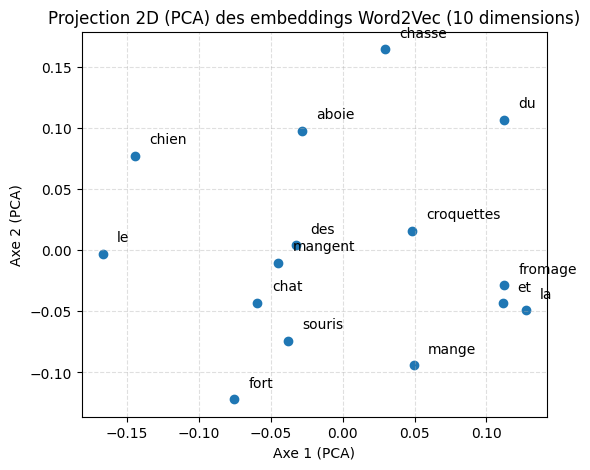

In [6]:
# !pip install -q scikit-learn
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Récupération des vecteurs correspondants ---
X = np.array([w2v_small.wv[w] for w in words])

# --- Réduction de dimension (PCA) ---
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

# --- Visualisation PCA ---
plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1])

for i, w in enumerate(words):
    plt.annotate(w, (X2[i, 0] + 0.01, X2[i, 1] + 0.01))

plt.title("Projection 2D (PCA) des embeddings Word2Vec (10 dimensions)")
plt.xlabel("Axe 1 (PCA)")
plt.ylabel("Axe 2 (PCA)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()




### 💭 Question — Visualisation PCA des vecteurs Word2Vec

Observez la projection **PCA** de vos vecteurs Word2Vec dans le plan 2D.

1. Quels **groupes de mots** semblent se former dans la visualisation ?  
Les mots qui apparaissent dans les mêmes phrases sont proches 

   - Certains mots apparaissent-ils plus proches les uns des autres ?
Les mots qui sont dans les mêmes phrases.

   - Ces proximités sont-elles cohérentes avec le contenu de votre corpus ?

2. Peut-on **interpréter le sens des axes** du plan (axe 1 et axe 2) ?  
   - Correspondent-ils à des catégories sémantiques (ex. “animaux”, “actions”)  
     ou à des **combinaisons statistiques** sans signification explicite ?

3. **Modifiez le corpus** (en ajoutant de nouvelles phrases) puis **réentraînez le modèle**  
   -  Parvenez-vous à modifier la **position des mots** ?  Si oui, expliquez comment. 


### A.2 — Modèle **FastText** (corpus jouet) 

Contrairement à Word2Vec, FastText représente les mots à partir de leurs sous-unités (n-grams de caractères), ce qui permet de gérer les formes fléchies (variations grammaticales d'un mot: genre, nombre, conjugaison, superlatif, ...) et même certains mots inconnus.
Vous allez tester ce modèle sur le même corpus avec des paramètres semblables pour comparer avec Word2Vec.  

### 1 — Entrainez un modèle fastText sur le même corpus que Word2Vec avec les mêmes paramètres  
-  Recherchez les 5 voisins de chat  
-  Calculez la similarité cosinus (chat, chien) 

In [7]:
ft_model = FastText(vector_size=10, window=2, min_count=1, sg=1)
ft_model.build_vocab(sentences)
ft_model.train(sentences, total_examples=ft_model.corpus_count, epochs=200)

print("5 voisins les plus proches de 'chat' :")
pprint(ft_model.wv.most_similar("chat", topn=5))

sim_ft = ft_model.wv.similarity("chat", "chien")
print(f"Similarité cosinus('chat', 'chien') avec FastText = {sim_ft:.4f}")


5 voisins les plus proches de 'chat' :
[('fromage', 0.4159970283508301),
 ('mangent', 0.3605912923812866),
 ('et', 0.32040613889694214),
 ('mange', 0.30632227659225464),
 ('chien', 0.25931617617607117)]
Similarité cosinus('chat', 'chien') avec FastText = 0.2593


### 💭 Questions
- Comparez les résultats obtenus avec ceux obtenus avec Word2Vec.

- Quelles différences remarquez-vous ? Comment les expliquez vous?


### 2 —  Recherches les voisins d'un **mot non présent dans le vocabulaire initial** (ex. `chats`, `chienne`) 


In [8]:
print("FastText — 5 voisins de 'chats' (mot non vu) :")
try:
    pprint(ft_model.wv.most_similar("chats", topn=5))
    v_chats = ft_model.wv["chats"]
    print("\nExtrait du vecteur FastText('chats') :", np.round(v_chats[:6], 4))
except KeyError as e:
    print("FastText KeyError :", e)

print("\nWord2Vec — 5 voisins de 'chats' (mot non vu) :")
try:
    pprint(w2v_small.wv.most_similar("chats", topn=5))
except KeyError:
    print("Erreur : 'chats' n'est pas dans le vocabulaire Word2Vec. Word2Vec ne peut pas générer de vecteur pour un mot OOV.")

FastText — 5 voisins de 'chats' (mot non vu) :
[('chat', 0.4507531225681305),
 ('chasse', 0.346222847700119),
 ('fromage', 0.30044400691986084),
 ('aboie', 0.28412073850631714),
 ('mange', 0.1336444467306137)]

Extrait du vecteur FastText('chats') : [-0.0068 -0.0167 -0.0002  0.018   0.0193 -0.0209]

Word2Vec — 5 voisins de 'chats' (mot non vu) :
Erreur : 'chats' n'est pas dans le vocabulaire Word2Vec. Word2Vec ne peut pas générer de vecteur pour un mot OOV.


- Quelles différences remarquées ?
    - Word2Vec donne une similarité chat–chien plus élevée (~0.3695) que FastText (~0.2593).
    - Les voisins/ordre diffèrent entre les deux modèles.
    - FastText génère un vecteur pour des forms non vues (ex. "chats" via v_chats) ; Word2Vec ne peut pas (KeyError).

- Comment expliquer ce résultat ?
    - Word2Vec apprend des vecteurs au niveau du mot entier à partir des co‑occurrences : si "chat" et "chien" apparaissent dans des contextes communs, leur cosinus augmente.
    - FastText compose les vecteurs à partir d'n‑grammes de caractères (sous‑mots) : il lisse l’information entre formes morphologiques et se base moins exclusivement sur une co‑occurrence mot‑à‑mot. Comme "chat" et "chien" partagent peu de n‑grammes, FastText ne les rapproche pas autant.
    - Sur un petit corpus, ces effets (et la variance d’entraînement) sont amplifiés — d’où des différences de scores et d’ordres de voisins.


---
# Partie B — Utiliser un modèle FastText pré‑entraîné (réduit)

But : explorer similarité & analogies sur un grand vocabulaire.

- En pratique, on utilise souvent des **embeddings pré-entraînés** sur de très grands corpus.  
- Ici : vecteurs **FastText** de Facebook/Meta, entraînés sur *Common Crawl*.  
- Fichier original (≈1,3 Go) : [cc.fr.300.vec.gz](https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.vec.gz)  
- Pour ce TP : **version réduite** à **100 000 mots** → fichiers à récupérer sur Teams (`cc.fr.100k.kv`et `cc.fr.100k.kv.vectors.npy` 
  - Plus léger (~150 Mo)  
  - Chargement rapide  
  - Suffisant pour vos expériences


### B.1 — Similarité & voisins


### 1 — Chargez un modèle fastText pré-entrainé 

In [10]:

# !pip install -q gensim gensim-downloader

# from pathlib import Path
# from gensim.models import KeyedVectors


def load_pretrained(fr_kv="cc.fr.100k.kv"):
    """
    Charge uniquement le modèle réduit local (100k mots en français).
    Nécessite les fichiers :
      - cc.fr.100k.kv
      - cc.fr.100k.kv.vectors.npy
    dans le même dossier que ce notebook.
    """
    if Path(fr_kv).exists():
        m = KeyedVectors.load(fr_kv)
        return m, "FR_reduit_kv (local)"
    else:
        raise FileNotFoundError(
            f"Fichier {fr_kv} introuvable. "
            "👉 Vérifiez que cc.fr.100k.kv et cc.fr.100k.kv.vectors.npy "
            "sont dans le même dossier que le notebook."
        )

# Chargement du modèle réduit
MODEL, SOURCE = load_pretrained("cc.fr.100k.kv")

print("Modèle chargé depuis :", SOURCE)
print("Dimension des vecteurs :", MODEL.vector_size)
print("Taille vocab :", len(MODEL.key_to_index))


Modèle chargé depuis : FR_reduit_kv (local)
Dimension des vecteurs : 300
Taille vocab : 100000


### 2 — Recherchez et affichez les 5 plus proches voisins de `chat` et la similarité sémantique (chat,chien)
Que remarquez vous ? 

In [12]:
try:
    print("5 voisins les plus proches de 'chat' :")
    pprint(MODEL.most_similar("chat", topn=5))
except KeyError:
    print("Erreur : 'chat' n'est pas dans le vocabulaire du modèle.")

try:
    sim_chat_chien = MODEL.similarity("chat", "chien")
    print(f"\nSimilarité cosinus('chat','chien') = {sim_chat_chien:.4f}")
except KeyError:
    print("Erreur : 'chat' ou 'chien' n'est pas dans le vocabulaire du modèle.")


5 voisins les plus proches de 'chat' :
[('chaton', 0.7561287879943848),
 ('chats', 0.7383633255958557),
 ('matou', 0.7298635244369507),
 ('chien', 0.7275363802909851),
 ('Chat', 0.6963930726051331)]

Similarité cosinus('chat','chien') = 0.7275


### 3 — Calculez les similarités cosinus :  `(roi, reine)`, `(roi, président)`, `(roi, château)`  
→ Notez les scores & proposez une interprétation 


In [14]:
pairs = [("roi", "reine"), ("roi", "président"), ("roi", "château")]

for a, b in pairs:
    try:
        sim = MODEL.similarity(a, b)
        print(f"Similarité cosinus('{a}', '{b}') = {sim:.4f}")
    except KeyError:
        print(f"Erreur : '{a}' ou '{b}' n'est pas dans le vocabulaire du modèle.")

for w in ("roi", "reine"):
    try:
        print(f"\n5 voisins les plus proches de '{w}':")
        pprint(MODEL.most_similar(w, topn=5))
    except KeyError:
        print(f"'{w}' n'est pas dans le vocabulaire du modèle.")


Similarité cosinus('roi', 'reine') = 0.6317
Similarité cosinus('roi', 'président') = 0.4080
Similarité cosinus('roi', 'château') = 0.4028

5 voisins les plus proches de 'roi':
[('Roi', 0.8430112600326538),
 ('monarque', 0.7603071928024292),
 ('souverain', 0.7244199514389038),
 ('royaume', 0.7038922309875488),
 ('prince', 0.7036827206611633)]

5 voisins les plus proches de 'reine':
[('Reine', 0.8237941265106201),
 ('princesse', 0.6878156661987305),
 ('reines', 0.6772192716598511),
 ('roi', 0.631697952747345),
 ('duchesse', 0.5895416140556335)]



### B.2 — Analogies 
Une formule vectorielle (motA − motB + motC) est utile quand on veut trouver un mot dans la même relation que celle observée entre deux autres mots.  
Cela permet de répondre aux questions du type: Quels mots sont à C ce que A est à B?  <BR><BR>
  *Remarque* : Si l'on veut simplement voir quels mots sont proches de 'roi'', on utilise directement most_similar("roi"), pas une formule.  
  
  ### 1 —  Testez l'analogie `roi − homme + femme`  
   
→ A quelle question implicite cela permet-il de répondre ?  
→ Interprétez le résultat



In [15]:

#   `roi − homme + femme` 
MODEL.most_similar(positive=["roi","femme"], negative=["homme"], topn=10)    


[('reine', 0.7286716103553772),
 ('Roi', 0.644017219543457),
 ('Reine', 0.6009510159492493),
 ('princesse', 0.5982300639152527),
 ('fille', 0.558933675289154),
 ('monarque', 0.546502411365509),
 ('belle-sœur', 0.5344110727310181),
 ('belle-mère', 0.5327216386795044),
 ('duchesse', 0.5320666432380676),
 ('belle-fille', 0.526075541973114)]

### 2 —  Recherche par analogie  
  
  On souhaite rechercher la capitale de l'Italie  
  
→ Essayez most_similar("Italie") → que remarquez-vous ?  
→ Reformulez la question avec une  analogie utilisant la capitale de la France  
→ Commentez le résultat


In [17]:
try:
    print("5 voisins les plus proches de 'Italie' :")
    pprint(MODEL.most_similar("Italie", topn=10))
except KeyError:
    print("Erreur : 'Italie' n'est pas dans le vocabulaire du modèle.")

try:
    print("\nAnalogie: 'Italie' + 'Paris' - 'France' (rechercher la capitale de l'Italie) :")
    analogy_res = MODEL.most_similar(positive=["Italie", "Paris"], negative=["France"], topn=10)
    pprint(analogy_res)

    if analogy_res:
        top_word, top_score = analogy_res[0]
        print(f"\nMot le plus similaire trouvé : {top_word} (score {top_score:.4f})")
        if "Rome" in MODEL.key_to_index:
            print(f"Similarité entre '{top_word}' et 'Rome' = {MODEL.similarity(top_word, 'Rome'):.4f}")
except KeyError as e:
    print("KeyError :", e)


5 voisins les plus proches de 'Italie' :
[('italie', 0.7392852306365967),
 ('Espagne', 0.6981151700019836),
 ('Toscane', 0.6798574924468994),
 ('Sicile', 0.6744078397750854),
 ('Naples', 0.6611614227294922),
 ('Lombardie', 0.6479058265686035),
 ('Gênes', 0.6471715569496155),
 ('Allemagne', 0.6360390186309814),
 ('Ligurie', 0.6351480484008789),
 ('Europe', 0.6331619024276733)]

Analogie: 'Italie' + 'Paris' - 'France' (rechercher la capitale de l'Italie) :
[('Turin', 0.6632146239280701),
 ('Naples', 0.6581746935844421),
 ('Milan', 0.6479010581970215),
 ('Palerme', 0.6294687986373901),
 ('Rome', 0.6274556517601013),
 ('Gênes', 0.6222734451293945),
 ('Bologne', 0.5978935360908508),
 ('Vérone', 0.583754301071167),
 ('Venise', 0.582973301410675),
 ('Padoue', 0.5737357139587402)]

Mot le plus similaire trouvé : Turin (score 0.6632)
Similarité entre 'Turin' et 'Rome' = 0.6461


### 3 — Analogies et polysémie :  Testez le mot batterie.

Quels sont ses 10 voisins les plus proches ?

Voyez-vous plusieurs sens mélangés ?

In [18]:
from pprint import pprint

# --- Recherche des 10 voisins de 'batterie' et exploration rapide de la polysémie ---

try:
    voisins = MODEL.most_similar("batterie", topn=10)
    print("10 voisins les plus proches de 'batterie' :")
    pprint(voisins)
except KeyError:
    print("Erreur : 'batterie' n'est pas dans le vocabulaire du modèle.")
    voisins = []

# --- Analyse simple : repérage d'indices de sens 'musical' vs 'énergie' ---
music_kw = {"percussion", "orchestre", "musique", "tambour", "rythme", "batteur"}
energy_kw = {"énergie", "accumulateur", "pile", "recharge", "charge", "batteries", "cellule", "coupure"}

voix_mots = [w for w, _ in voisins]
music_hits = [w for w in voix_mots if w in music_kw]
energy_hits = [w for w in voix_mots if w in energy_kw]

print("\nMots voisins extraits :", voix_mots)
print(f"\nApparitions dans lexique 'musical'   : {music_hits} (count={len(music_hits)})")
print(f"Apparitions dans lexique 'énergie'    : {energy_hits} (count={len(energy_hits)})")

# Affichage des similarités aux quelques mots représentatifs (utile pour interprétation)
check_words = ["percussion", "musique", "énergie", "pile", "recharge"]
print("\nSimilarités avec quelques mots-repères :")
for cw in check_words:
    try:
        print(f"  similarity('batterie', '{cw}') = {MODEL.similarity('batterie', cw):.4f}")
    except KeyError:
        print(f"  '{cw}' absent du vocabulaire du modèle.")

10 voisins les plus proches de 'batterie' :
[('batteries', 0.7712229490280151),
 ('Batterie', 0.7476932406425476),
 ('chargeur', 0.6207422614097595),
 ('contrebasse', 0.5943222641944885),
 ('guitare', 0.58347487449646),
 ('lithium-ion', 0.5683061480522156),
 ('recharge', 0.5254812836647034),
 ('rechargeable', 0.524258553981781),
 ('piles', 0.5222518444061279),
 ('Li-ion', 0.5187150835990906)]

Mots voisins extraits : ['batteries', 'Batterie', 'chargeur', 'contrebasse', 'guitare', 'lithium-ion', 'recharge', 'rechargeable', 'piles', 'Li-ion']

Apparitions dans lexique 'musical'   : [] (count=0)
Apparitions dans lexique 'énergie'    : ['batteries', 'recharge'] (count=2)

Similarités avec quelques mots-repères :
  similarity('batterie', 'percussion') = 0.4815
  similarity('batterie', 'musique') = 0.4287
  similarity('batterie', 'énergie') = 0.3692
  similarity('batterie', 'pile') = 0.4954
  similarity('batterie', 'recharge') = 0.5255


### 4 — Calculez les similarités Cosinus avec MODEL.similarity(mot1, mot2) pour comparer les similarités entre 'batterie' et :  
- des mots du champ **musical** : `percussion`, `orchestre`, `musique`  
- des mots du champ **énergie** : `énergie`, `smartphone`, `recharge`  <BR>Qu’observez-vous ? 

In [ ]:

# A COMPLETER


### 5 — Calculez et comparez les **distances cosinus** (MODEL.distances(mot1, [m1, m2, ...]) entre `avion` et deux groupes de mots :  

- Groupe **transport aérien** : `vol`, `aéroport`, `pilote`  
- Groupe **jeu / papier plié** : `jouet`, `pliage`, `papier`  
 
- Quels sont les scores obtenus pour chaque groupe ?  
- Quelle interprétation peut-on faire de la différence entre les deux ?  


In [ ]:
# A COMPLETER



### 6 - Identifiez et expliquez la limite des embeddings statiques mise en évidence dans les questions précédentes   
Observe-t-on un mélange de sens ?
